In [1]:
# In snn_training.ipynb

# --- Configure system path to find the snn_model.py file ---
import sys
import os
# Go up one directory from 'notebooks/' to the project root, then into 'src/'
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- 1. Import Libraries and Define Parameters ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# Now this import will work correctly because we've set the path
from snn_model import SNN

print("Libraries imported successfully!")

# --- Parameters for the real dataset ---
num_timesteps = 200  # Number of time steps per sample
num_inputs = 8       # Number of EMG channels
num_classes = 8      # Number of gestures (7 active + 1 rest)

# --- 2. Load REAL Data ---
# Load the FINAL spike data and the original labels
X_data = torch.from_numpy(np.load('../data/processed/spike_trains.npy')).float()
y_data = torch.from_numpy(np.load('../data/processed/y.npy')).long()

# Create a PyTorch DataLoader to handle batching
dataset = TensorDataset(X_data, y_data)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"\nReal data loaded successfully!")
print(f"Data shape: {X_data.shape}")
print(f"Labels shape: {y_data.shape}")

Libraries imported successfully!

Real data loaded successfully!
Data shape: torch.Size([3635, 200, 8])
Labels shape: torch.Size([3635])


In [2]:
# --- 2. Initialize Model, Loss, and Optimizer ---

# Define the network's parameters
num_hidden = 64      # Number of neurons in the hidden layer
num_outputs = num_classes # The number of gestures we want to classify

# Create an instance of our SNN model from the other file
model = SNN(num_inputs=num_inputs, num_hidden=num_hidden, num_outputs=num_outputs)

# Define the loss function
loss_fn = nn.CrossEntropyLoss()

# Define the optimizer to update our model's weights
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print("Model, loss function, and optimizer have been initialized successfully!")
print("\nOur SNN model architecture is:")
print(model)

Model, loss function, and optimizer have been initialized successfully!

Our SNN model architecture is:
SNN(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=64, out_features=8, bias=True)
  (lif2): Leaky()
)


In [3]:
# --- 3. The Training Loop ---

num_epochs = 10  # We will loop through the data 10 times
loss_hist = []
acc_hist = []

# The main training loop
for epoch in range(num_epochs):
    # This inner loop goes through batches of data
    for i, (data, targets) in enumerate(train_loader):
        # 1. Forward pass: Feed the data to the model
        outputs = model(data)

        # 2. Calculate loss (the error)
        loss = loss_fn(outputs, targets)

        # 3. Backward pass and optimization (the learning part)
        optimizer.zero_grad() # Reset gradients
        loss.backward()       # Calculate new gradients
        optimizer.step()      # Update model weights

    # --- Validation: Check accuracy at the end of each epoch ---
    with torch.no_grad():
        model.eval() # Set model to evaluation mode

        # Check accuracy on the whole (real) dataset
        outputs = model(X_data)
        _, predicted = torch.max(outputs.data, 1)

        total = y_data.size(0)
        correct = (predicted == y_data).sum().item()

        accuracy = 100 * correct / total

        # Store history for plotting later
        acc_hist.append(accuracy)
        loss_hist.append(loss.item())

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.2f}%")

        model.train() # Set model back to training mode for the next epoch

print("\n--- Training Finished ---")

# --- 4. Save the Trained Model to the correct folder ---
# The path ../src/trained_models/ assumes this notebook is in the notebooks/ folder
torch.save(model.state_dict(), '../src/trained_models/model.pt')
print("\nModel weights saved to ../src/trained_models/model.pt")

Epoch 1/10, Loss: 3.5336, Accuracy: 61.68%
Epoch 2/10, Loss: 0.1274, Accuracy: 88.89%
Epoch 3/10, Loss: 0.0000, Accuracy: 94.20%
Epoch 4/10, Loss: 0.0002, Accuracy: 96.81%
Epoch 5/10, Loss: 2.1322, Accuracy: 96.73%
Epoch 6/10, Loss: 0.0000, Accuracy: 98.07%
Epoch 7/10, Loss: 0.0000, Accuracy: 98.49%
Epoch 8/10, Loss: 0.0026, Accuracy: 98.54%
Epoch 9/10, Loss: 0.1538, Accuracy: 98.90%
Epoch 10/10, Loss: 0.1349, Accuracy: 98.95%

--- Training Finished ---

Model weights saved to ../src/trained_models/model.pt


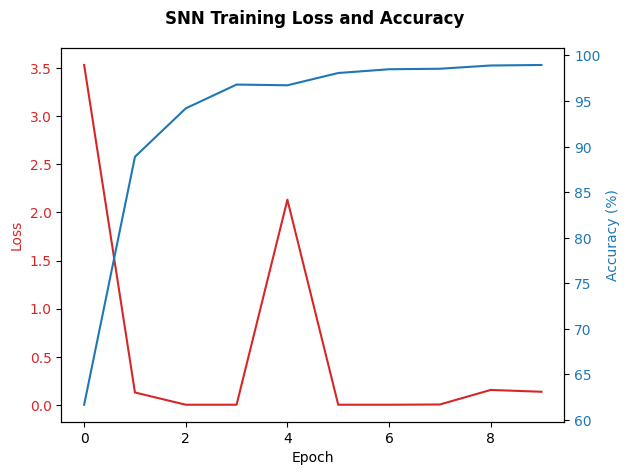

In [4]:
# --- 5. Plot Training History ---

fig, ax1 = plt.subplots()

# Plot Loss on the first y-axis
color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color=color)
ax1.plot(loss_hist, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis to plot Accuracy on the same graph
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Accuracy (%)', color=color)
ax2.plot(acc_hist, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('SNN Training Loss and Accuracy', fontweight='bold')
fig.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()